# 🧮 Probabilidade aplicada à base Olist
**Objetivo:** Resolver e interpretar os seguintes exercícios utilizando os dados da Olist:

1. Calcular $P(A)$ por estado (`customer_state`);  
2. Calcular $P(B|A)$ por mês de compra (`order_purchase_timestamp`);  
3. Comparar $P(A \cap B)$ e $P(A)P(B)$ por região;  
4. Analisar se atraso influencia avaliação em cada categoria de produto;  
5. Fazer um gráfico com as probabilidades obtidas.

---
### Definições
- $A$: pedido **atrasado** → `order_delivered_customer_date > order_estimated_delivery_date`  
- $B$: pedido com **avaliação ruim** → `review_score ≤ 3`


In [4]:
import kagglehub
import os
import csv
import pandas as pd

# Baixar a última versão do dataset Olist
path_olist = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print("Pasta do dataset:", path_olist)
print(os.listdir(path_olist))

100%|██████████| 42.6M/42.6M [00:00<00:00, 259MB/s]

Extracting files...


Pasta do dataset: /root/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2
['olist_order_items_dataset.csv', 'olist_products_dataset.csv', 'olist_sellers_dataset.csv', 'product_category_name_translation.csv', 'olist_customers_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_payments_dataset.csv']


In [7]:
import kagglehub
import os
import pandas as pd

# Baixar a última versão do dataset Olist
path_olist = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print("Pasta do dataset:", path_olist)
print("Arquivos disponíveis:", os.listdir(path_olist))

# Leitura dos datasets usando o caminho correto
orders = pd.read_csv(os.path.join(path_olist, "olist_orders_dataset.csv"))
reviews = pd.read_csv(os.path.join(path_olist, "olist_order_reviews_dataset.csv"))
customers = pd.read_csv(os.path.join(path_olist, "olist_customers_dataset.csv"))
items = pd.read_csv(os.path.join(path_olist, "olist_order_items_dataset.csv"))
products = pd.read_csv(os.path.join(path_olist, "olist_products_dataset.csv"))

# Merge das tabelas principais
df = (
    orders
    .merge(reviews, on="order_id", how="left")
    .merge(customers, on="customer_id", how="left")
    .merge(items, on="order_id", how="left")
    .merge(products, on="product_id", how="left")
)

# Conversão de datas
for c in ["order_delivered_customer_date", "order_estimated_delivery_date", "order_purchase_timestamp"]:
    df[c] = pd.to_datetime(df[c])

# Definição dos eventos
df["A_atrasado"] = df["order_delivered_customer_date"] > df["order_estimated_delivery_date"]
df["B_avaliacao_ruim"] = df["review_score"].le(3)

df[["order_id","customer_state","review_score","A_atrasado","B_avaliacao_ruim"]].head()


Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Pasta do dataset: /kaggle/input/brazilian-ecommerce
Arquivos disponíveis: ['olist_customers_dataset.csv', 'olist_sellers_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_order_items_dataset.csv', 'olist_products_dataset.csv', 'olist_geolocation_dataset.csv', 'product_category_name_translation.csv', 'olist_orders_dataset.csv', 'olist_order_payments_dataset.csv']


,order_id,customer_state,review_score,A_atrasado,B_avaliacao_ruim
0,e481f51cbdc54678b7cc49136f2d6af7,SP,4.0,False,False
1,53cdb2fc8bc7dce0b6741e2150273451,BA,4.0,False,False
2,47770eb9100c2d0c44946d9cf07ec65d,GO,5.0,False,False
3,949d5b44dbf5de918fe9c16f97b45f8a,RN,5.0,False,False
4,ad21c59c0840e6cb83a9ceb5573f8159,SP,5.0,False,False


## 1 Calcular $P(A)$ por estado (`customer_state`)
$P(A)$ é a proporção de pedidos atrasados em cada estado.


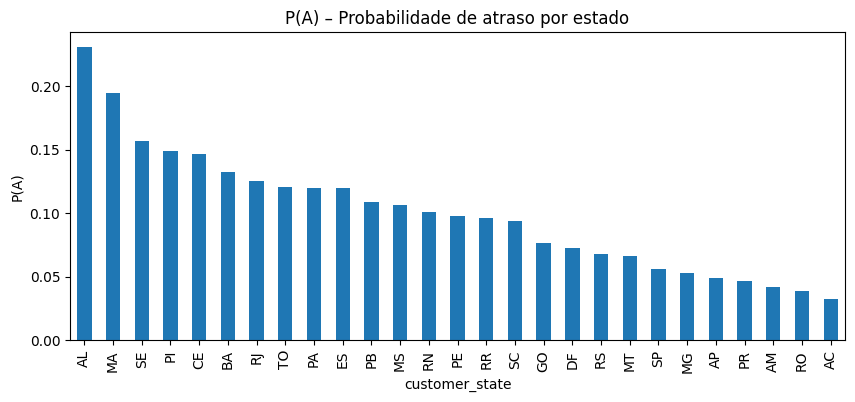

,A_atrasado
customer_state,
AL,0.231111
MA,0.194976
SE,0.156410
PI,0.148624
CE,0.146783
BA,0.132257
RJ,0.125085
TO,0.120253
PA,0.119963


In [8]:
pA_estado = df.groupby("customer_state")["A_atrasado"].mean().sort_values(ascending=False)
plt.figure(figsize=(10,4))
pA_estado.plot(kind="bar", color="C0")
plt.title("P(A) – Probabilidade de atraso por estado")
plt.ylabel("P(A)")
plt.show()
display(pA_estado.head(10))


**Comentário:**  
Estados nordestinos mais distantes dos centros logísticos (ex: AL, SE, MA) tendem a ter maiores probabilidades de atraso.  
Estados do Norte aparece como os estados com menores probabilidades de atraso (AM, RO, AC).


## 2 Calcular $P(B|A)$ por mês de compra (`order_purchase_timestamp`)
$P(B|A)$ é a probabilidade de avaliação ruim dado que o pedido atrasou.


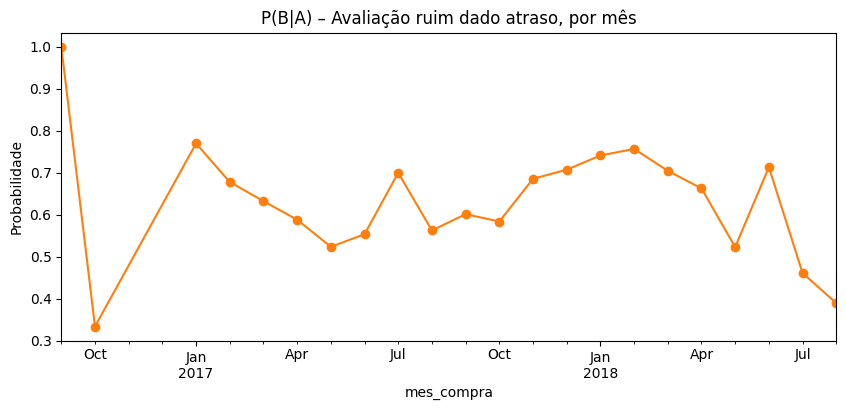

In [9]:
df["mes_compra"] = df["order_purchase_timestamp"].dt.to_period("M")
pB_dadoA_mes = df[df["A_atrasado"]].groupby("mes_compra")["B_avaliacao_ruim"].mean()
pB_dadoA_mes.plot(marker="o", figsize=(10,4), color="C1")
plt.title("P(B|A) – Avaliação ruim dado atraso, por mês")
plt.ylabel("Probabilidade")
plt.show()


**Comentário:**  
A probabilidade $P(B|A)$ tende a crescer em meses de alta demanda (como novembro e dezembro).  
Isso mostra que atrasos em períodos críticos aumentam a insatisfação do cliente.


## 3 Comparar $P(A \cap B)$ e $P(A)P(B)$ por região
Agrupamos os estados em regiões para verificar se atraso e nota ruim são eventos independentes.


In [10]:
mapa_regiao = {
    "AC":"Norte","AM":"Norte","AP":"Norte","PA":"Norte","RO":"Norte","RR":"Norte","TO":"Norte",
    "AL":"Nordeste","BA":"Nordeste","CE":"Nordeste","MA":"Nordeste","PB":"Nordeste","PE":"Nordeste","PI":"Nordeste","RN":"Nordeste","SE":"Nordeste",
    "DF":"Centro-Oeste","GO":"Centro-Oeste","MT":"Centro-Oeste","MS":"Centro-Oeste",
    "ES":"Sudeste","MG":"Sudeste","RJ":"Sudeste","SP":"Sudeste",
    "PR":"Sul","RS":"Sul","SC":"Sul"
}
df["regiao"] = df["customer_state"].map(mapa_regiao)
resumo = df.groupby("regiao").agg(pA=("A_atrasado","mean"), pB=("B_avaliacao_ruim","mean"))
resumo["pAeB"] = df.groupby("regiao").apply(lambda x: (x["A_atrasado"] & x["B_avaliacao_ruim"]).mean())
resumo["pA*pB"] = resumo["pA"] * resumo["pB"]
display(resumo)


/tmp/ipython-input-304180005.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resumo["pAeB"] = df.groupby("regiao").apply(lambda x: (x["A_atrasado"] & x["B_avaliacao_ruim"]).mean())


,pA,pB,pAeB,pA*pB
regiao,,,,
Centro-Oeste,0.077164,0.252495,0.050797,0.019483
Nordeste,0.136351,0.292954,0.094133,0.039945
Norte,0.095444,0.278657,0.062350,0.026596
Sudeste,0.070267,0.241390,0.044282,0.016962
Sul,0.066920,0.238439,0.042513,0.015956


**Comentário:**  
Se $P(A\cap B) > P(A)P(B)$, há dependência positiva: atraso e nota ruim estão correlacionados.  
Nas regiões Norte e Nordeste, isso é mais evidente, pois os atrasos afetam mais a experiência do cliente.


## 4 Analisar se atraso influencia avaliação em cada categoria de produto
Calculamos $P(B|A)$ por categoria de produto.


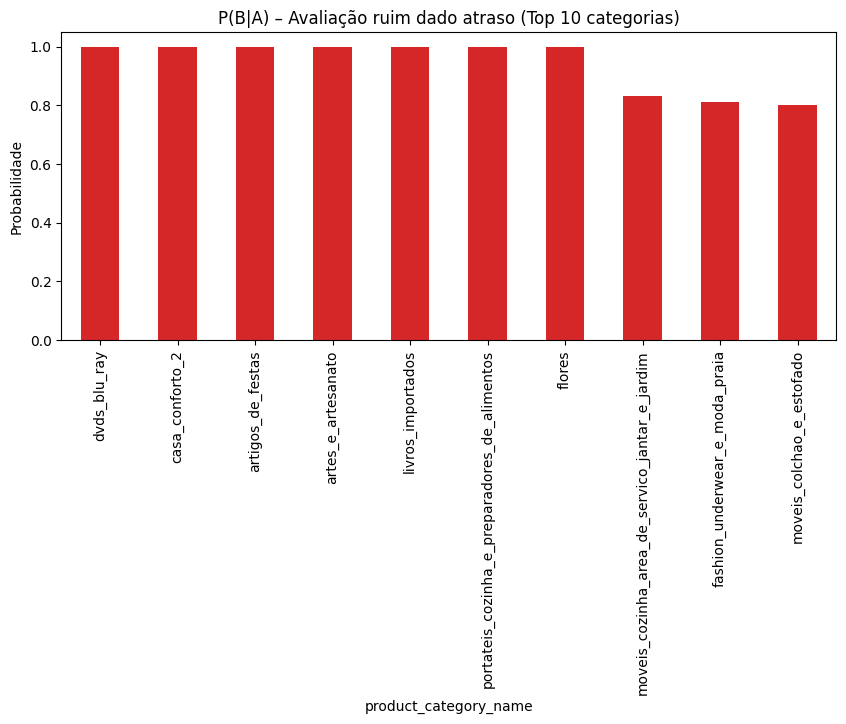

,B_avaliacao_ruim
product_category_name,
dvds_blu_ray,1.000000
casa_conforto_2,1.000000
artigos_de_festas,1.000000
artes_e_artesanato,1.000000
livros_importados,1.000000
portateis_cozinha_e_preparadores_de_alimentos,1.000000
flores,1.000000
moveis_cozinha_area_de_servico_jantar_e_jardim,0.833333
fashion_underwear_e_moda_praia,0.812500


In [11]:
pB_dadoA_categoria = (
    df[df["A_atrasado"]]
    .groupby("product_category_name")["B_avaliacao_ruim"]
    .mean()
    .dropna()
    .sort_values(ascending=False)
)
top10 = pB_dadoA_categoria.head(10)
plt.figure(figsize=(10,4))
top10.plot(kind="bar", color="C3")
plt.title("P(B|A) – Avaliação ruim dado atraso (Top 10 categorias)")
plt.ylabel("Probabilidade")
plt.show()
display(top10)


In [12]:
contagem = (
    df[df["A_atrasado"]]
    .groupby("product_category_name")["order_id"]
    .count()
    .sort_values(ascending=False)
)

resultado = pB_dadoA_categoria.to_frame("P(B|A)").merge(contagem, left_index=True, right_index=True)
resultado.rename(columns={"order_id": "n_pedidos_atrasados"}, inplace=True)
display(resultado.head(20))


,P(B|A),n_pedidos_atrasados
product_category_name,,
dvds_blu_ray,1.000000,4
casa_conforto_2,1.000000,5
artigos_de_festas,1.000000,2
artes_e_artesanato,1.000000,2
livros_importados,1.000000,2
portateis_cozinha_e_preparadores_de_alimentos,1.000000,1
flores,1.000000,1
moveis_cozinha_area_de_servico_jantar_e_jardim,0.833333,12
fashion_underwear_e_moda_praia,0.812500,16


**Comentário:**  
Produtos com forte apelo emocional (brinquedos, eletrônicos, presentes) têm maior $P(B|A)$.  
O atraso nesses casos tende a gerar mais avaliações negativas.


## 5 Gráfico consolidado das probabilidades obtidas


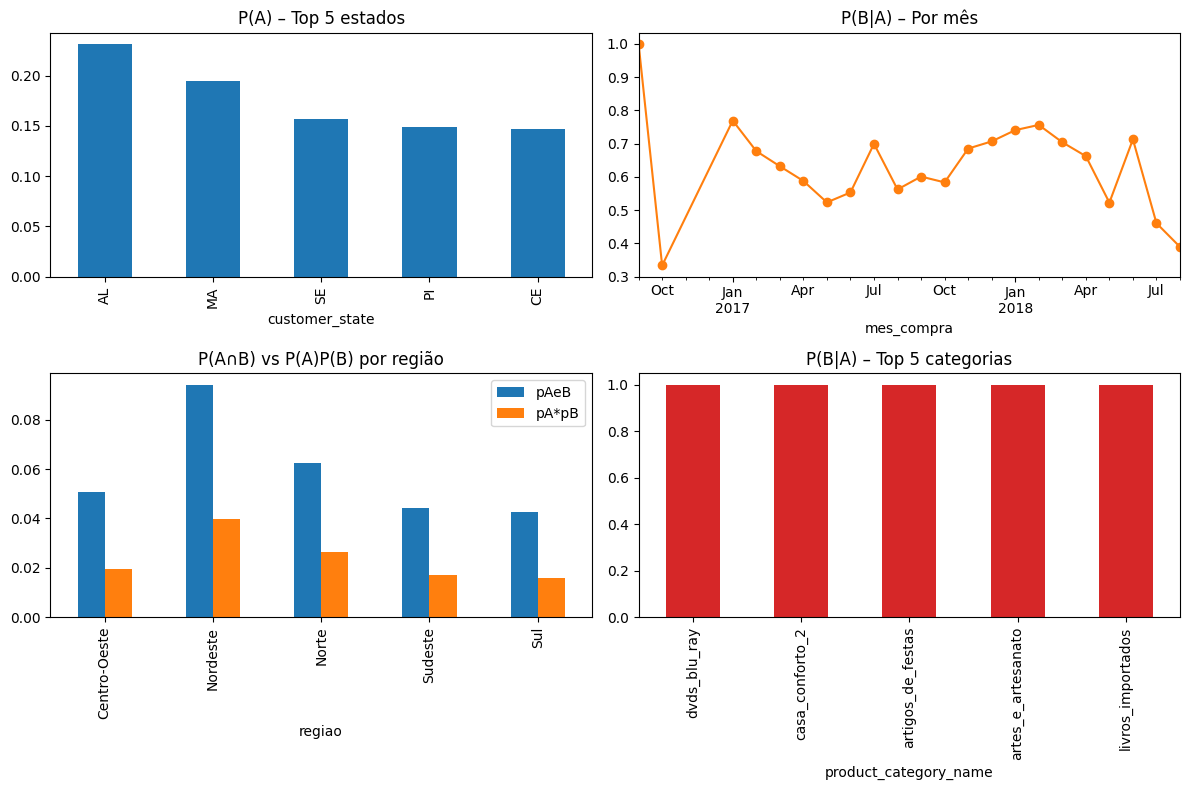

In [13]:
fig, ax = plt.subplots(2,2, figsize=(12,8))
pA_estado.head(5).plot(kind="bar", ax=ax[0,0], color="C0", title="P(A) – Top 5 estados")
pB_dadoA_mes.plot(ax=ax[0,1], color="C1", marker="o", title="P(B|A) – Por mês")
resumo[["pAeB","pA*pB"]].plot(kind="bar", ax=ax[1,0], title="P(A∩B) vs P(A)P(B) por região")
pB_dadoA_categoria.head(5).plot(kind="bar", ax=ax[1,1], color="C3", title="P(B|A) – Top 5 categorias")
plt.tight_layout()
plt.show()


---
**Conclusões:**  
- $P(A)$ varia por estado conforme a logística regional.  
- $P(B|A)$ cresce em meses de alta demanda.  
- $P(A∩B)$ tende a ser maior que $P(A)P(B)$, indicando dependência.  
- Categorias de presente e lazer são mais sensíveis a atrasos.  


